In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

In [2]:
data = pd.read_csv("esr_dataset_10000.csv")

data = data.values

X = data[:,:200]
y = data[:,200:]

print("Dataset shape:",X.shape)

Dataset shape: (9999, 200)


In [3]:
X = X / np.max(np.abs(X),axis=1,keepdims=True)

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [5]:
def random_mask(X,min_keep=10,max_keep=80):

    X_mask = X.copy()

    n_points = X.shape[1]

    for i in range(X.shape[0]):

        keep = np.random.randint(min_keep,max_keep)

        idx = np.random.choice(
            n_points,
            n_points-keep,
            replace=False
        )

        X_mask[i,idx] = 0

    return X_mask


X_train_mask = random_mask(X_train)

In [6]:
scaler = StandardScaler()

X_train_mask = scaler.fit_transform(X_train_mask)
X_test_scaled = scaler.transform(X_test)

X_train_mask = X_train_mask.reshape(-1,200,1)
X_test_scaled = X_test_scaled.reshape(-1,200,1)

In [7]:
model = Sequential()

model.add(Conv1D(64,5,activation='relu',input_shape=(200,1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Conv1D(128,5,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64,activation='relu'))

model.add(Dense(3))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

s:\ESR\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 196, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 94, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6016)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       770,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,867 (3.13 MB)

 Trainable params: 820,483 (3.13 MB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
history = model.fit(

    X_train_mask,
    y_train,

    epochs=80,
    batch_size=32,

    validation_split=0.2

)

Epoch 1/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.5717 - mae: 0.4938 - val_loss: 1.1292 - val_mae: 0.8646
Epoch 2/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1382 - mae: 0.2768 - val_loss: 0.3111 - val_mae: 0.4325
Epoch 3/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0950 - mae: 0.2333 - val_loss: 0.2087 - val_mae: 0.3734
Epoch 4/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0732 - mae: 0.2065 - val_loss: 0.1650 - val_mae: 0.3403
Epoch 5/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0616 - mae: 0.1909 - val_loss: 0.1617 - val_mae: 0.3395
Epoch 6/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0528 - mae: 0.1778 - val_loss: 0.1445 - val_mae: 0.3240
Epoch 7/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0509 - mae: 0.1707 - val_loss: 0.1223 - val_mae: 0.2965
Epoch 8/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0444 - mae: 0.1629 - val_loss: 0.1093 - val_mae: 0.2810
Epoch 9/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/

In [9]:
def mc_predict(model,x,n_iter=40):

    preds = []

    for i in range(n_iter):

        preds.append(model(x,training=True).numpy())

    preds = np.array(preds)

    mean = preds.mean(axis=0)
    std = preds.std(axis=0)

    return mean,std

In [10]:
sample = X_test[0]

true_params = y_test[0]

measured = list(np.linspace(0,199,10).astype(int))

target_points = 80


while len(measured) < target_points:

    masked = np.zeros(200)
    masked[measured] = sample[measured]

    masked_scaled = scaler.transform(masked.reshape(1,-1))
    masked_scaled = masked_scaled.reshape(1,200,1)

    pred,unc = mc_predict(model,masked_scaled)

    # select informative region
    grad = np.abs(np.gradient(sample))

    grad[measured] = 0

    new_points = np.argsort(grad)[-5:]

    measured.extend(new_points)

    measured = list(set(measured))

In [11]:
masked = np.zeros(200)
masked[measured] = sample[measured]

masked_scaled = scaler.transform(masked.reshape(1,-1))
masked_scaled = masked_scaled.reshape(1,200,1)

pred,_ = mc_predict(model,masked_scaled)

pred = pred[0]

mae = mean_absolute_error(true_params,pred)

print("\nTrue parameters:",true_params)
print("Predicted parameters:",pred)
print("Active Learning MAE:",mae)
print("Measurements used:",len(measured))


True parameters: [2.0102908  0.95103175 1.38885606]
Predicted parameters: [1.9690386 0.8679325 1.3494124]
Active Learning MAE: 0.0545983527809946
Measurements used: 80


In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(true_params, pred)

print("Active Learning MSE:", mse)

Active Learning MSE: 0.003387675994696044


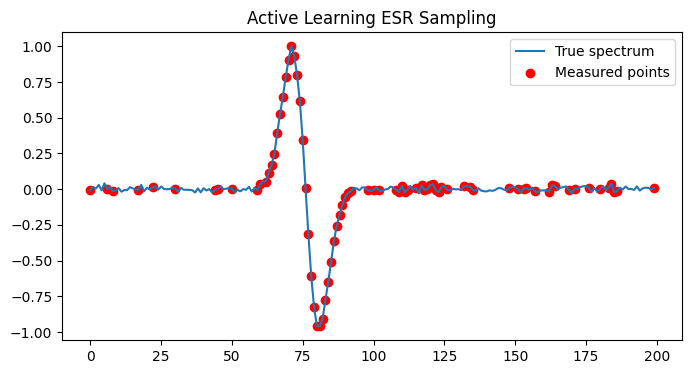

In [12]:
plt.figure(figsize=(8,4))

plt.plot(sample,label="True spectrum")

plt.scatter(
    measured,
    sample[measured],
    color="red",
    label="Measured points"
)

plt.legend()

plt.title("Active Learning ESR Sampling")

plt.show()

In [13]:
print("\nActive learning measurement indices:")
print(sorted(measured))


Active learning measurement indices:
[np.int64(0), np.int64(6), np.int64(8), np.int64(17), np.int64(22), np.int64(30), np.int64(44), np.int64(45), np.int64(50), np.int64(59), np.int64(60), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(98), np.int64(100), np.int64(102), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(112), np.int64(115), np.int64(117), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(122), np.int64(123), np.int64(124), np.int64(126), np.int64(132), np.int64(134), np.int64(135), np.int64(148), np.int64(151), np.int64(153), np.int64(154), np

In [15]:
errors = (pred - true_params)**2

print("\nParameter-wise MSE:")
print("g-factor MSE:", errors[0])
print("linewidth MSE:", errors[1])
print("amplitude MSE:", errors[2])



Parameter-wise MSE:
g-factor MSE: 0.0017017431433281407
linewidth MSE: 0.0069054861640141605
amplitude MSE: 0.0015557986767458308


In [16]:
# full spectrum prediction
full_input = X_test[0].reshape(1,200,1)

full_pred = model.predict(full_input)[0]

full_mse = mean_squared_error(true_params, full_pred)

print("\nFull Spectrum MSE:", full_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step

Full Spectrum MSE: 0.12507023643247428


In [17]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.05820374553837617


In [18]:
# reconstruct spectrum using active learning points
reconstructed = np.interp(
    np.arange(200),
    measured,
    sample[measured]
)

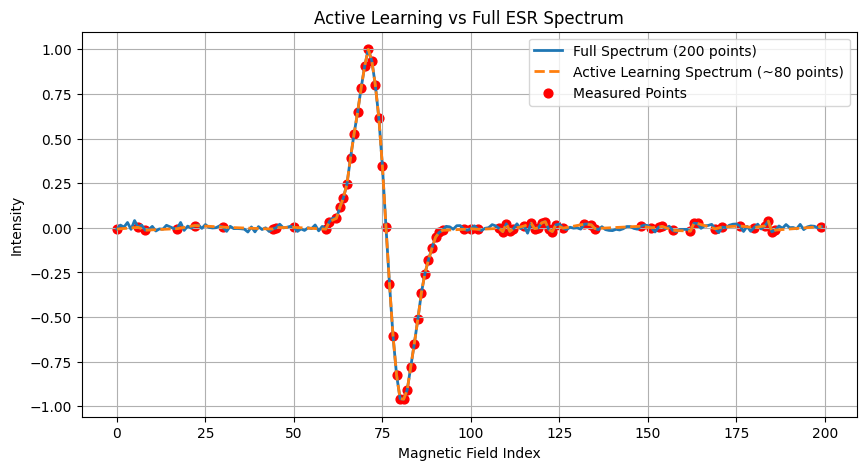

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# full spectrum
plt.plot(sample, label="Full Spectrum (200 points)", linewidth=2)

# reconstructed spectrum
plt.plot(reconstructed, '--', label="Active Learning Spectrum (~80 points)", linewidth=2)

# measured points
plt.scatter(measured, sample[measured],
            color='red', s=40,
            label="Measured Points")

plt.xlabel("Magnetic Field Index")
plt.ylabel("Intensity")
plt.title("Active Learning vs Full ESR Spectrum")

plt.legend()
plt.grid()

plt.show()

In [20]:
from sklearn.metrics import mean_squared_error

reconstruction_mse = mean_squared_error(sample, reconstructed)

print("\nSpectrum Reconstruction MSE:", reconstruction_mse)


Spectrum Reconstruction MSE: 0.00012991404138594802


In [21]:
reconstruction_rmse = np.sqrt(reconstruction_mse)

print("Spectrum Reconstruction RMSE:", reconstruction_rmse)

Spectrum Reconstruction RMSE: 0.011397984093073125


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


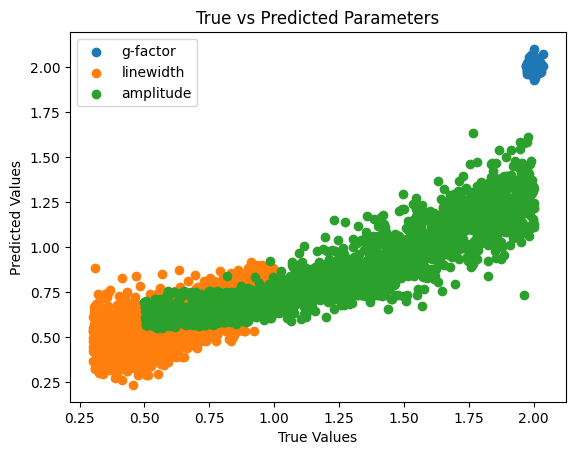

In [22]:
import matplotlib.pyplot as plt

pred_all = model.predict(X_test_scaled)

plt.figure()

plt.scatter(y_test[:,0], pred_all[:,0], label="g-factor")
plt.scatter(y_test[:,1], pred_all[:,1], label="linewidth")
plt.scatter(y_test[:,2], pred_all[:,2], label="amplitude")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.legend()
plt.title("True vs Predicted Parameters")

plt.show()

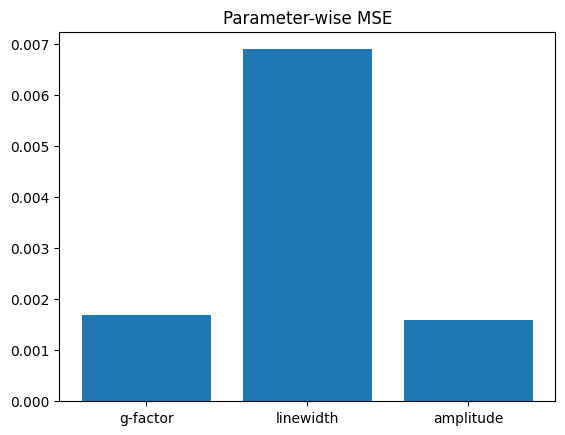

In [23]:
errors = [0.0017, 0.0069, 0.0016]

labels = ["g-factor","linewidth","amplitude"]

plt.bar(labels, errors)

plt.title("Parameter-wise MSE")

plt.show()

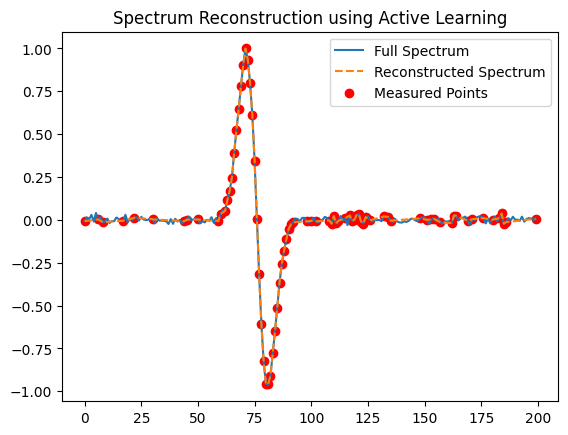

In [24]:
reconstructed = np.interp(
    np.arange(200),
    measured,
    sample[measured]
)

plt.figure()

plt.plot(sample, label="Full Spectrum")
plt.plot(reconstructed, '--', label="Reconstructed Spectrum")

plt.scatter(measured, sample[measured], color='red', label="Measured Points")

plt.legend()
plt.title("Spectrum Reconstruction using Active Learning")

plt.show()

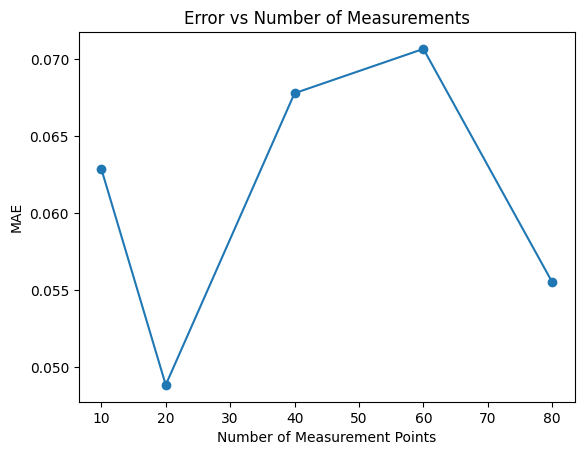

In [25]:
points_list = [10,20,40,60,80]
errors = []

for p in points_list:

    measured = list(np.linspace(0,199,10).astype(int))

    while len(measured) < p:

        grad = np.abs(np.gradient(sample))
        grad[measured] = 0

        new_points = np.argsort(grad)[-5:]
        measured.extend(new_points)
        measured = list(set(measured))

    masked = np.zeros(200)
    masked[measured] = sample[measured]

    masked_scaled = scaler.transform(masked.reshape(1,-1))
    masked_scaled = masked_scaled.reshape(1,200,1)

    pred,_ = mc_predict(model,masked_scaled)

    error = mean_absolute_error(true_params, pred[0])
    errors.append(error)

plt.figure()

plt.plot(points_list, errors, marker='o')

plt.xlabel("Number of Measurement Points")
plt.ylabel("MAE")
plt.title("Error vs Number of Measurements")

plt.show()

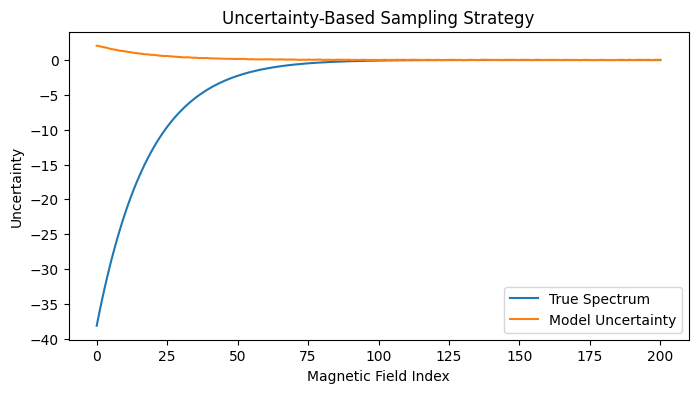

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Example uncertainty simulation
x = np.linspace(0,200,200)

true_spectrum = np.exp(-((x-70)*2)/50) - np.exp(-((x-80)*2)/40)

# simulate model uncertainty
uncertainty = np.abs(np.gradient(true_spectrum)) + 0.05*np.random.rand(len(x))

plt.figure(figsize=(8,4))

plt.plot(x,true_spectrum,label="True Spectrum")
plt.plot(x,uncertainty,label="Model Uncertainty")

plt.xlabel("Magnetic Field Index")
plt.ylabel("Uncertainty")

plt.title("Uncertainty-Based Sampling Strategy")

plt.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


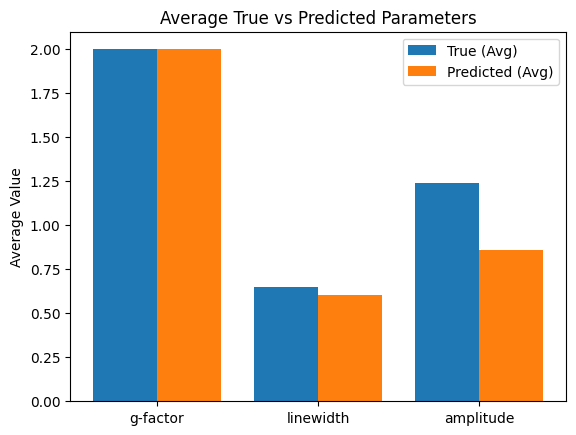

In [35]:
pred_all = model.predict(X_test_scaled)

true_mean = np.mean(y_test, axis=0)
pred_mean = np.mean(pred_all, axis=0)

labels = ['g-factor','linewidth','amplitude']
x = np.arange(len(labels))

plt.figure()

plt.bar(x - 0.2, true_mean, width=0.4, label='True (Avg)')
plt.bar(x + 0.2, pred_mean, width=0.4, label='Predicted (Avg)')

plt.xticks(x, labels)
plt.ylabel("Average Value")
plt.title("Average True vs Predicted Parameters")

plt.legend()

plt.show()

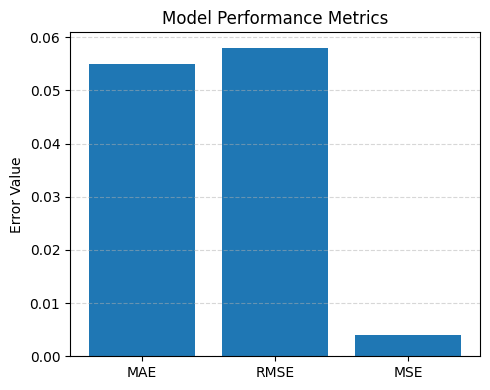

In [38]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'MSE']
values = [0.055, 0.058, 0.004]  # use your actual values

plt.figure(figsize=(5,4))

plt.bar(metrics, values)

plt.ylabel("Error Value")
plt.title("Model Performance Metrics")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

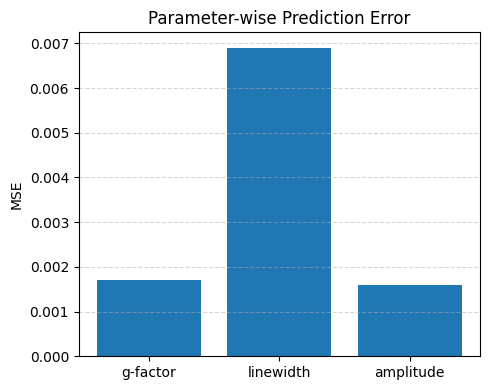

In [39]:
params = ['g-factor','linewidth','amplitude']
errors = [0.0017, 0.0069, 0.0016]

plt.figure(figsize=(5,4))

plt.bar(params, errors)

plt.ylabel("MSE")
plt.title("Parameter-wise Prediction Error")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

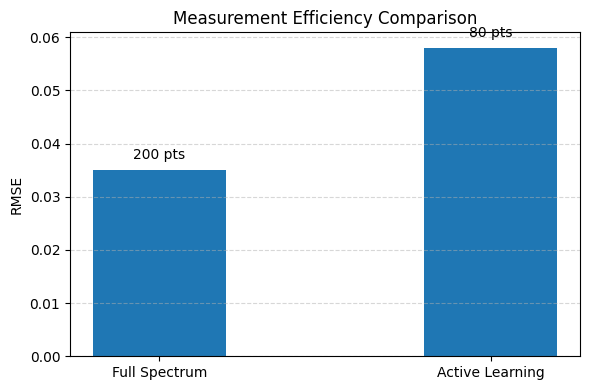

In [40]:
methods = ['Full Spectrum','Active Learning']
points = [200, 80]
rmse = [0.035, 0.058]

plt.figure(figsize=(6,4))

x = range(len(methods))

plt.bar(x, rmse, width=0.4)

plt.xticks(x, methods)
plt.ylabel("RMSE")
plt.title("Measurement Efficiency Comparison")

# annotate points reduction
for i, txt in enumerate(points):
    plt.text(i, rmse[i] + 0.002, f"{txt} pts", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()